# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os
import time
#from matplotlib.backends.backend_pdf import PdfPages
exec(open('../functions/03_indice_calculation_functions.py').read())


## Simulation output

In [2]:
def indice_dataframe(simu_sets_paths,typeSimu='mps'):
    '''
    Input: 
    simu_sets_paths : path to the folder containing the different folder set of simulation.
    typeSimu : 'mps' or 'sgs'for mps and sgs simulations - 'krig' for kriging estimate.
    output : A list of dataframe, one dataframe for each simulations sets.
    '''

    all_output = []
    real_vol   = []
    type_sim   = ['MPS','GRF']
    simulation_name = sorted(os.listdir(simu_sets_paths))[:]
    
    
    if typeSimu == 'mps' or typeSimu == 'sgs':
        #It goes through each set of simulation
        for name in simulation_name:

            with open(simu_sets_paths+name,'rb') as file:
                trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)

            trueMNT += trend_cut
            for i, simus in enumerate(simu_sets):        
                if np.all(simus != None):           
                    simus += trend_cut
                    indice_out = indice_calculationV(trueMNT, simus, typeSimu)
                    all_output.append([name[:-7],trueMNT, type_sim[i]]+indice_out)
                    
    elif typeSimu =='krig':               
        for name in simulation_name:
            with open(simu_sets_paths+name,'rb') as file:
                trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)
                
            trueMNT      += trend_cut
            simu_sets[0] += trend_cut

            indice_out = indice_calculationV(trueMNT, simu_sets, typeSimu)
            all_output.append([name[:-7],trueMNT, 'KRIG']+indice_out)
    
    else:
        print('Type error !')


                 
    results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','TrueMNT','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])
    
    return results_frame

|        | n  | t     | f   |
|--------|----|-------|-----|
| Set 00 | 6  | 0.01  | 0.1 |
| Set 01 | 6  | 0.01  | 0.5 |
| Set 02 | 6  | 0.005 | 0.1 |
| Set 03 | 6  | 0.005 | 0.5 |
| Set 04 | 12 | 0.01  | 0.1 |
| Set 05 | 12 | 0.01  | 0.5 |
| Set 06 | 12 | 0.005 | 0.1 |
| Set 07 | 12 | 0.005 | 0.5 |
| Set 08 | 24 | 0.01  | 0.1 |
| Set 09 | 24 | 0.01  | 0.5 |
| Set 10 | 24 | 0.005 | 0.1 |
| Set 11 | 24 | 0.005 | 0.5 |

### MPS simulation

In [3]:
path_sets_mps = '../simulation_outputs/mps_trend/'
list_sets_mps = sorted(os.listdir(path_sets_mps))[:]
list_sets_mps

['simulation_set_00',
 'simulation_set_01',
 'simulation_set_02',
 'simulation_set_03',
 'simulation_set_04',
 'simulation_set_05',
 'simulation_set_06',
 'simulation_set_07',
 'simulation_set_08',
 'simulation_set_09',
 'simulation_set_10',
 'simulation_set_11']

In [4]:
with open(path_sets_mps+list_sets_mps[0]+'/simulation_realisation00.pickle','rb') as d:
    trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(d)

In [5]:
all_results_mps = []
for name_set in list_sets_mps:
    all_results_mps.append(indice_dataframe(path_sets_mps+name_set+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:154: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:154: RuntimeWarning: invalid value encountered in true_divide


In [6]:
all_results_mps[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,simulation_realisation00,"[[2493.061, 2492.7922, 2492.5662, 2492.216, 24...",MPS,-4.182800,12.463564,1.342237,"[[2492.5398966471353, 2492.6044260660806, 2492...","[[0.544931779298235, 0.504986579530964, 0.4201...","[9034581.266235363, 9332298.337890632, 8625949...",8000000.0
1,simulation_realisation01,"[[2557.1199, 2557.1174, 2557.2632, 2557.528, 2...",MPS,1.413596,10.889817,1.300965,"[[2556.8899129231772, 2556.702880859375, 2556....","[[0.4489390562149161, 0.5569000175156776, 0.46...","[7652666.074707037, 7535789.637939475, 6950625...",8000000.0
2,simulation_realisation02,"[[2515.8735, 2515.2854, 2515.157, 2515.2869, 2...",MPS,-1.523722,10.485678,1.231142,"[[2514.3362630208335, 2514.1664123535156, 2514...","[[0.5692171336722287, 0.34629430573265785, 0.3...","[8334756.824218757, 8722262.849121107, 9843320...",8000000.0
3,simulation_realisation03,"[[2330.7004, 2330.4749, 2330.0488, 2329.417, 2...",MPS,1.251796,13.632174,1.307647,"[[2330.3652140299478, 2330.006317138672, 2329....","[[0.33483395642605945, 0.42920932352834823, 0....","[8376806.10974122, 7321075.79370116, 6888891.7...",8000000.0
4,simulation_realisation04,"[[2302.042, 2301.7983, 2301.447, 2301.023, 230...",MPS,2.036999,10.324747,1.312036,"[[2301.8626505533853, 2301.4996439615884, 2301...","[[0.355832245345475, 0.4339276579112694, 0.283...","[7522546.045776378, 8248954.207397473, 7787304...",8000000.0
5,simulation_realisation05,"[[2482.1143, 2481.9485, 2481.7485, 2481.7014, ...",MPS,0.175609,10.937153,1.292067,"[[2481.556162516276, 2481.1424153645835, 2480....","[[0.35031797377531626, 0.35465761825307457, 1....","[7665002.659790048, 7597570.614379902, 8204867...",8000000.0
6,simulation_realisation06,"[[2596.1743, 2596.197, 2596.3286, 2596.5312, 2...",MPS,1.271639,10.447133,1.294845,"[[2596.100499471029, 2596.0020192464194, 2595....","[[0.45798597775753697, 0.6685417582102895, 0.5...","[7733508.956420914, 7528789.107788103, 7885573...",8000000.0
7,simulation_realisation07,"[[2373.55, 2372.0571, 2370.9956, 2370.1296, 23...",MPS,-1.160112,11.003966,1.462767,"[[2372.9464416503906, 2371.343063354492, 2370....","[[0.4264326220552245, 0.6601665586427993, 0.51...","[8391750.417724619, 8602199.859741213, 8359034...",8000000.0
8,simulation_realisation08,"[[2291.8894, 2292.1338, 2292.1912, 2292.0347, ...",MPS,1.428860,10.278242,1.267560,"[[2291.107838948568, 2291.3435974121094, 2291....","[[0.40976655842494947, 0.5670264819119829, 0.3...","[7412230.50561525, 7767791.749755864, 7900021....",8000000.0
9,simulation_realisation09,"[[2422.1382, 2421.3113, 2420.4216, 2419.455, 2...",MPS,3.848254,11.693895,1.457240,"[[2420.8426717122397, 2420.0540364583335, 2419...","[[0.35607570431086016, 0.36508482604285925, 0....","[6533791.828857431, 8173244.505126963, 6964860...",8000000.0


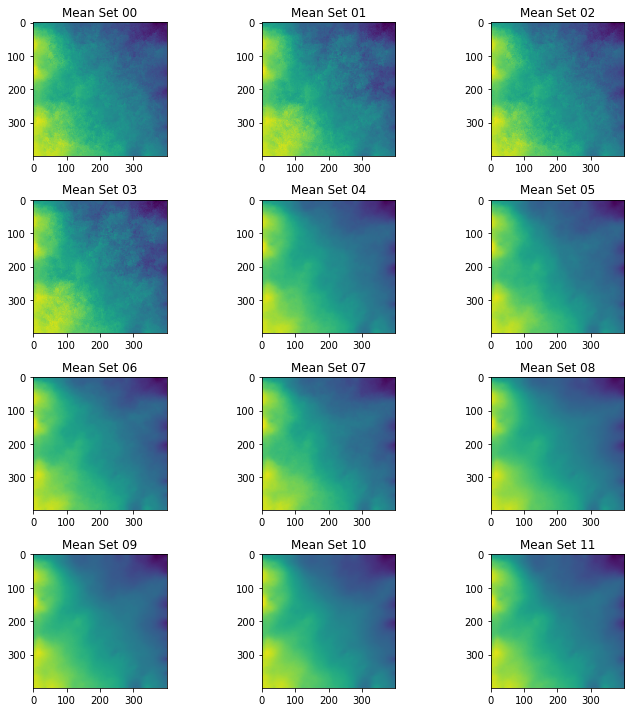

In [7]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
simu_nb=0
for i in range(len(all_results_mps)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results_mps[i].Mean[simu_nb])
    plt.title('Mean Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [8]:
fig[0].savefig('../images/mean_maps_MPS_test00.png')

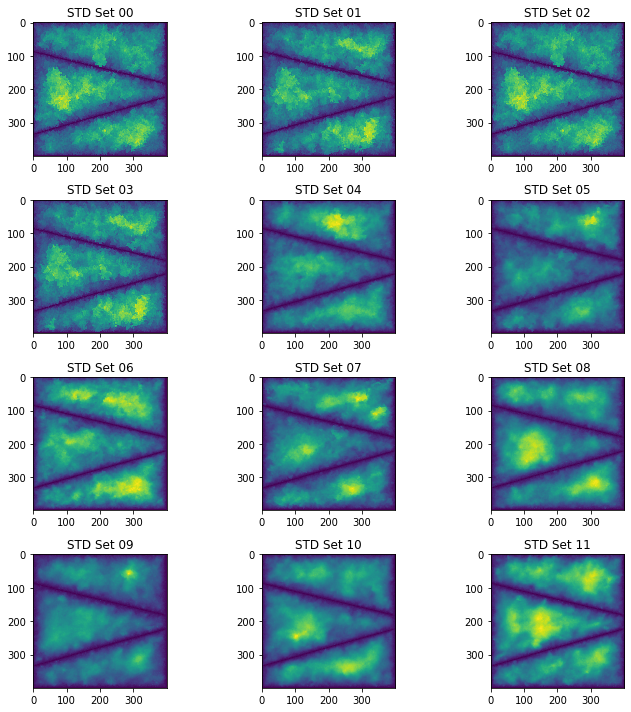

In [59]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
simu_nb = 0
for i in range(len(all_results_mps)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results_mps[i].Sd[simu_nb])
    plt.title('STD Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [10]:
fig[0].savefig('../images/std_maps_mps_test00.png')

### SGS simulations

In [25]:
path_sets_sgs = '../simulation_outputs/sgs/'
list_sets_sgs = sorted(os.listdir(path_sets_sgs))[:]
list_sets_sgs

['simulation_realisation00.pickle',
 'simulation_realisation01.pickle',
 'simulation_realisation02.pickle',
 'simulation_realisation03.pickle',
 'simulation_realisation04.pickle',
 'simulation_realisation05.pickle',
 'simulation_realisation06.pickle',
 'simulation_realisation07.pickle',
 'simulation_realisation08.pickle',
 'simulation_realisation09.pickle',
 'simulation_realisation10.pickle',
 'simulation_realisation11.pickle']

In [26]:
all_results_sgs = []
all_results_sgs.append(indice_dataframe(path_sets_sgs+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:154: RuntimeWarning: invalid value encountered in true_divide


In [27]:
all_results_sgs[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,simulation_realisation00,"[[2493.061, 2492.7922, 2492.5662, 2492.216, 24...",GRF,-3.600165,8.751781,1.471826,"[[2493.06103515625, 2492.792236328125, 2492.56...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8484224.900922816, 8466394.881832983, 8980899...",8000000.0
1,simulation_realisation01,"[[2557.1199, 2557.1174, 2557.2632, 2557.528, 2...",GRF,2.034529,8.175824,1.549951,"[[2557.119873046875, 2557.117431640625, 2557.2...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7436840.501900466, 7674946.2048228225, 756824...",8000000.0
2,simulation_realisation02,"[[2515.8735, 2515.2854, 2515.157, 2515.2869, 2...",GRF,1.136500,7.466845,1.378758,"[[2515.87353515625, 2515.285400390625, 2515.15...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7857451.982868725, 8199768.529774635, 7588955...",8000000.0
3,simulation_realisation03,"[[2330.7004, 2330.4749, 2330.0488, 2329.417, 2...",GRF,2.409910,8.220413,1.322907,"[[2330.700439453125, 2330.474853515625, 2330.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7647321.095741557, 7059816.424393216, 7310838...",8000000.0
4,simulation_realisation04,"[[2302.042, 2301.7983, 2301.447, 2301.023, 230...",GRF,2.120677,7.901134,1.767042,"[[2302.0419921875, 2301.79833984375, 2301.4470...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7761081.409208798, 7624176.640442326, 7414674...",8000000.0
5,simulation_realisation05,"[[2482.1143, 2481.9485, 2481.7485, 2481.7014, ...",GRF,-1.464854,7.973248,1.518577,"[[2482.1142578125, 2481.948486328125, 2481.748...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8054893.150637517, 8612303.464138322, 7857495...",8000000.0
6,simulation_realisation06,"[[2596.1743, 2596.197, 2596.3286, 2596.5312, 2...",GRF,-0.089289,7.541922,1.508882,"[[2596.17431640625, 2596.197021484375, 2596.32...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7771514.234985655, 7847626.342126482, 7905500...",8000000.0
7,simulation_realisation07,"[[2373.55, 2372.0571, 2370.9956, 2370.1296, 23...",GRF,0.917307,7.859694,1.720502,"[[2373.550048828125, 2372.05712890625, 2370.99...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7629425.899087052, 8058230.180278349, 7733045...",8000000.0
8,simulation_realisation08,"[[2291.8894, 2292.1338, 2292.1912, 2292.0347, ...",GRF,0.760440,6.944374,1.352961,"[[2291.889404296875, 2292.1337890625, 2292.191...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8057996.293433979, 7763770.545462353, 7608436...",8000000.0
9,simulation_realisation09,"[[2422.1382, 2421.3113, 2420.4216, 2419.455, 2...",GRF,3.713148,8.824297,1.804200,"[[2422.13818359375, 2421.311279296875, 2420.42...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7561587.474170707, 7015269.348196097, 7525128...",8000000.0


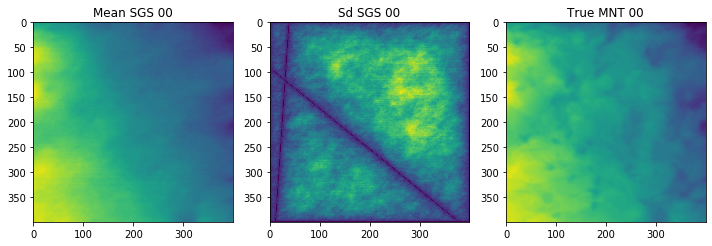

In [14]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(1,3,figsize=(10,10))
i=0
simu_nb=0

plt.subplot(1,3,1)
plt.imshow(all_results_sgs[i].Mean[simu_nb])
plt.title('Mean SGS {}'.format(str(i).zfill(2)))
plt.subplot(1,3,2)
plt.imshow(all_results_sgs[i].Sd[simu_nb])
plt.title('Sd SGS {}'.format(str(i).zfill(2)))
plt.subplot(1,3,3)
plt.imshow(all_results_sgs[i].TrueMNT[simu_nb])
plt.title('True MNT {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [15]:
fig[0].savefig('../images/sgs_test_noTrend00.png')

### Krig

In [19]:
path_sets_k = '../simulation_outputs/krig/'
list_sets_k = sorted(os.listdir(path_sets_k))[:]
list_sets_k

['simulation_realisation00.pickle',
 'simulation_realisation01.pickle',
 'simulation_realisation02.pickle',
 'simulation_realisation03.pickle',
 'simulation_realisation04.pickle',
 'simulation_realisation05.pickle',
 'simulation_realisation06.pickle',
 'simulation_realisation07.pickle',
 'simulation_realisation08.pickle',
 'simulation_realisation09.pickle',
 'simulation_realisation10.pickle',
 'simulation_realisation11.pickle']

In [23]:
all_results_k = []
all_results_k.append(indice_dataframe(path_sets_k+'/',typeSimu='krig'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:128: RuntimeWarning: invalid value encountered in true_divide


In [24]:
all_results_k[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,simulation_realisation00,"[[2493.061, 2492.7922, 2492.5662, 2492.216, 24...",KRIG,-2.591738,4.238049,0.338567,"[[2493.06103515625, 2492.792236328125, 2492.56...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8.408427e+06,8000000.0
1,simulation_realisation01,"[[2557.1199, 2557.1174, 2557.2632, 2557.528, 2...",KRIG,1.237976,4.183235,0.380444,"[[2557.119873046875, 2557.117431640625, 2557.2...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.805094e+06,8000000.0
2,simulation_realisation02,"[[2515.8735, 2515.2854, 2515.157, 2515.2869, 2...",KRIG,0.234688,3.236333,0.244461,"[[2515.87353515625, 2515.285400390625, 2515.15...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.963072e+06,8000000.0
3,simulation_realisation03,"[[2330.7004, 2330.4749, 2330.0488, 2329.417, 2...",KRIG,2.107807,3.915905,0.303262,"[[2330.700439453125, 2330.474853515625, 2330.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.668189e+06,8000000.0
4,simulation_realisation04,"[[2302.042, 2301.7983, 2301.447, 2301.023, 230...",KRIG,1.913624,4.686287,0.515636,"[[2302.0419921875, 2301.79833984375, 2301.4470...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.698723e+06,8000000.0
5,simulation_realisation05,"[[2482.1143, 2481.9485, 2481.7485, 2481.7014, ...",KRIG,-0.948609,4.389206,0.380331,"[[2482.1142578125, 2481.948486328125, 2481.748...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8.149492e+06,8000000.0
6,simulation_realisation06,"[[2596.1743, 2596.197, 2596.3286, 2596.5312, 2...",KRIG,-0.085652,3.899195,0.400487,"[[2596.17431640625, 2596.197021484375, 2596.32...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8.013488e+06,8000000.0
7,simulation_realisation07,"[[2373.55, 2372.0571, 2370.9956, 2370.1296, 23...",KRIG,0.949673,4.848806,0.574964,"[[2373.550048828125, 2372.05712890625, 2370.99...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.850699e+06,8000000.0
8,simulation_realisation08,"[[2291.8894, 2292.1338, 2292.1912, 2292.0347, ...",KRIG,0.701646,3.039565,0.257720,"[[2291.889404296875, 2292.1337890625, 2292.191...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.889690e+06,8000000.0
9,simulation_realisation09,"[[2422.1382, 2421.3113, 2420.4216, 2419.455, 2...",KRIG,4.356185,6.170806,0.822743,"[[2422.13818359375, 2421.311279296875, 2420.42...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7.314602e+06,8000000.0


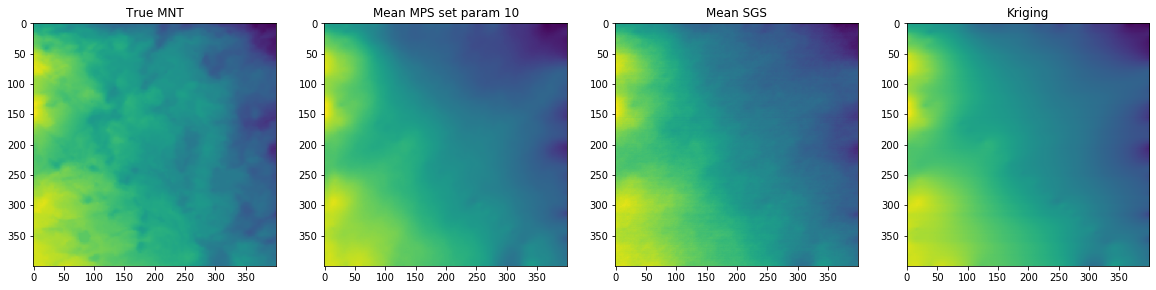

In [28]:
minV = all_results_mps[0].TrueMNT.values[0].min()
maxV = all_results_mps[0].TrueMNT.values[0].max()
simu_nb  = 0
set_para = 10
fig = plt.subplots(1,4,figsize=(20,20))
plt.subplot(1,4,1)
plt.imshow(all_results_mps[0].TrueMNT.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('True MNT')
plt.subplot(1,4,2)
plt.imshow(all_results_mps[set_para].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Mean MPS set param {}'.format(set_para))
plt.subplot(1,4,3)
plt.imshow(all_results_sgs[0].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Mean SGS')
plt.subplot(1,4,4)
plt.imshow(all_results_k[0].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Kriging')
plt.show()



In [29]:
fig[0].savefig('../images/meanSimu_{}.png'.format(simu_nb))

### Indice

In [30]:
from colour import Color
red = Color("navy")
colors = list(red.range_to(Color("lightblue"),12))

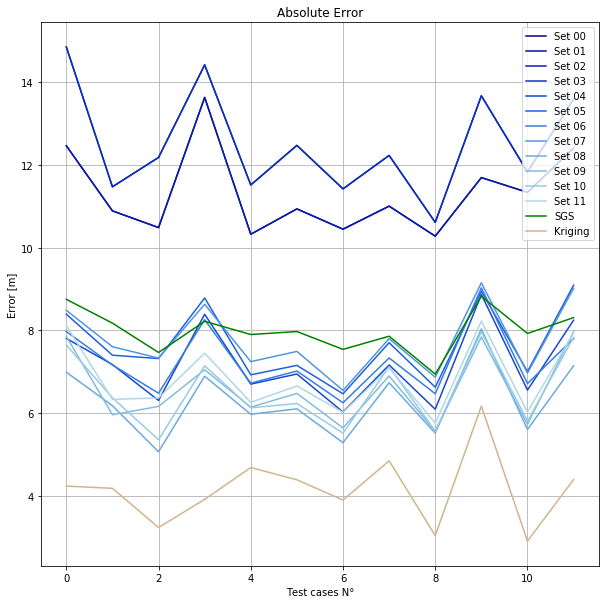

In [31]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Abs_error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
    
plt.plot(all_results_sgs[0].Abs_error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Abs_error.values, label='Kriging',color='tan')


plt.legend(loc=0)
plt.title('Absolute Error')
plt.xlabel('Test cases N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim()
plt.show()

In [32]:
fig.savefig('../images/abs_error.png')

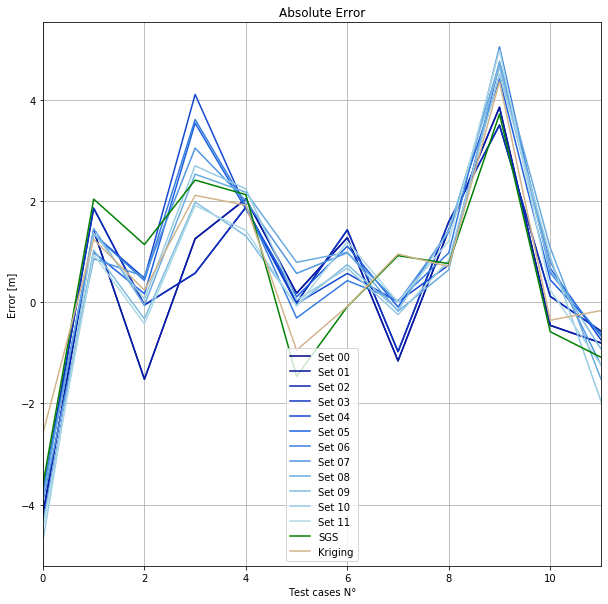

In [33]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
plt.plot(all_results_sgs[0].Error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Error.values, label='Kriging',color='tan')

plt.legend(loc=0)

plt.title('Absolute Error')
plt.xlabel('Test cases N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [34]:
fig.savefig('../images/error.png')

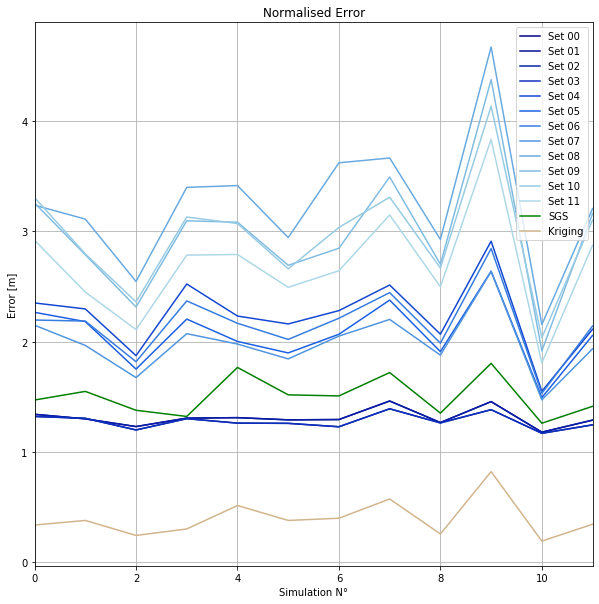

In [35]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Norm_Error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb )
plt.plot(all_results_sgs[0].Norm_Error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Norm_Error.values, label='Kriging',color='tan')


plt.legend(loc=0)
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [36]:
fig.savefig('../images/norm_error.png')

In [37]:
import seaborn as sns
#sns.set(color_codes=True)

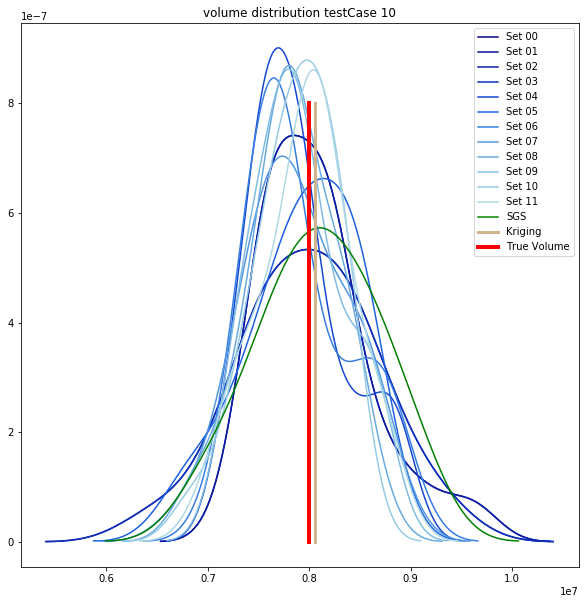

In [66]:
fig = plt.figure(figsize=(10,10))
simu_nb = 10
volumes = []

for i in range(len(all_results_mps)):
    volumes.append(all_results_mps[i].Volume.values[simu_nb])
        
    sns.distplot(volumes[i],hist=False, label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
sns.distplot(all_results_sgs[0].Volume.values[simu_nb],hist=False,label='SGS', color='green')
plt.plot([all_results_k[0].Volume.values[simu_nb],all_results_k[0].Volume.values[simu_nb]],[0,0.0000008],label='Kriging',linewidth=3, color='tan')

    
#sns.distplot(np.mean(all_results_sgs[0].Volume.values),hist=False, label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)

plt.plot([8000000,8000000],[0,0.0000008],label='True Volume',linewidth=4,color='red')
plt.legend(loc=1)
plt.title('volume distribution testCase {}'.format(simu_nb))

plt.show()

In [65]:
fig.savefig('../images/volume_distribution.png')

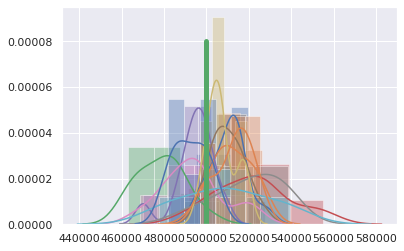

In [102]:
for i in range(12):
    sns.distplot(all_results[0].Volume.values[i])
plt.plot([500000,500000],[0,0.00008],label='True Volume',linewidth=5)


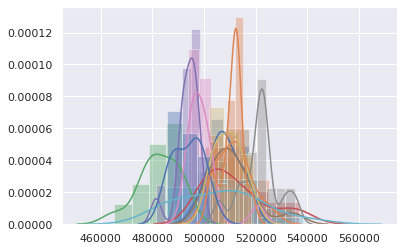

In [85]:
for i in range(12):
    sns.distplot(all_results[6].Volume.values[i])

Text(0.5, 0, 'Volume [m^2]')

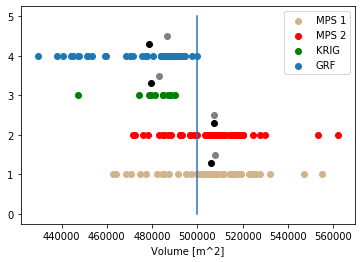

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')

## Kriging output

In [94]:
all_output = []
real_vol = []
type_sim = ['KRIG']
for name in simulation_name_krig:
    
    with open(path_output_krig+name,'rb') as file:
        trueMNT, simu_sets, mask_box_ti, position = pickle.load(file)

    if np.all(simu_sets != None):
        indice_out = indice_calculationV(trueMNT, simu_sets, 'krig')
        
        all_output.append([name[:-12], type_sim[0]] +indice_out)
        
        
results_frame_k = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:129: RuntimeWarning: invalid value encountered in true_divide


### OLD

Define the path of the data

In [2]:
path_output_krig = '../simulation_output_krig_set1/'
path_output_MPS  = '../simulation_output_set_trend_1/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)
simulation_name_krig = sorted(simulation_name_krig)
simulation_name = sorted(simulation_name)

exec(open('../functions/03_indice_calculation_functions.py').read())


FileNotFoundError: [Errno 2] No such file or directory: '../simulation_output_krig_set1/'

In [3]:
simulation_name[0:3], simulation_name_krig[0:3]

(['realisation0_simu.pickle',
  'realisation1_simu.pickle',
  'realisation2_simu.pickle'],
 ['realisation0_krige.pickle',
  'realisation1_krige.pickle',
  'realisation2_krige.pickle'])

In [4]:
with open(path_output_MPS+simulation_name[4],'rb') as file:
    simus_sets = pickle.load(file)

trueMNT, trend_cut,[extr2,None,simGRF],mask[1], ref

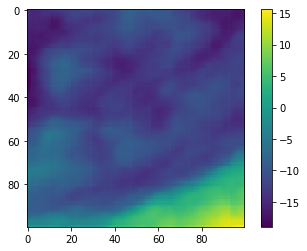

In [13]:
plt.imshow(simus_sets[0])
plt.colorbar()

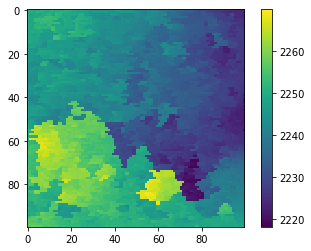

In [17]:
meanSS = np.add(simus_sets[1],simus_sets[2][0])
plt.imshow(meanSS[0])
plt.colorbar()

In [90]:
simus_sets[3]

array([2644, 2744,  791,  891])

In [91]:
a =[0,9]

In [92]:
np.all(a != None)

True

In [27]:
os.listdir('../')

['simulation_output_set_2',
 'Brouillon.ipynb',
 'simulation_trend',
 'generated_data',
 'real_data_cyprien',
 '.gitignore',
 '.ipynb_checkpoints',
 'simulation_output_krig_set1',
 'generated_data_test',
 'jupyter',
 'simulation_alexis',
 'old',
 'real_data',
 'simulation_output_set_trend_1',
 'data',
 'generated_data_old',
 '.git',
 'real_data_alexis',
 'simulation_output_set_1',
 'scripts',
 'functions',
 'README.md']

In [25]:
list_sets = ['set_1', 'set_2', 'set_trend_1']

In [20]:
all_output = []
real_vol = []
type_sim = ['MPS','GRF']
for name in simulation_name:
    
    with open(path_output_MPS+name,'rb') as file:
        trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)
        
    trueMNT += trend_cut
    for i, simus in enumerate(simu_sets):        
        if np.all(simus != None):
            
            simus = np.add(trend_cut, simus)

            indice_out = indice_calculationA(trueMNT, simus, 'mps')
        
            all_output.append([name[:-12], type_sim[i]]+indice_out)
        
        
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: invalid value encountered in true_divide


In [95]:
%xmode plain

Exception reporting mode: Plain


In [21]:
results_frame.head()

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,realisation0,MPS,-1.137077,3.473365,1.640604,"[[2292.2376098632812, 2291.9398193359375, 2292...","[[0.6354961329287337, 0.7535558192487, 1.26170...","[529913.2072753906, 519624.0041503906, 502368....",500000.0
1,realisation1,MPS,-0.809821,3.038069,1.434308,"[[2524.2253621419272, 2523.9181315104165, 2524...","[[1.2062203048612512, 1.1950727581098646, 1.36...","[509462.5642089844, 508942.0622558594, 512164....",500000.0
2,realisation2,MPS,-0.735828,3.422478,2.055130,"[[2150.6896362304688, 2150.8915201822915, 2150...","[[0.7870159685356458, 0.8745312305467324, 0.70...","[504601.732421875, 505222.9479980469, 506461.5...",500000.0
3,realisation3,MPS,-1.571266,5.550606,1.632712,"[[2308.6089680989585, 2308.3300984700522, 2308...","[[0.29112290034454436, 0.5815122236624358, 0.4...","[498774.00048828125, 504441.255859375, 497956....",500000.0
4,realisation4,MPS,1.752105,4.832653,2.234671,"[[2251.0850219726562, 2250.7294108072915, 2249...","[[0.4963154647772063, 0.4197275623948463, 2.65...","[474217.08935546875, 488717.57470703125, 47255...",500000.0


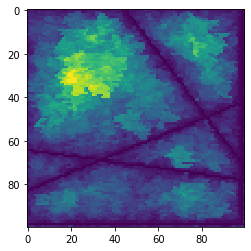

In [22]:
plt.imshow(results_frame.Sd[0])

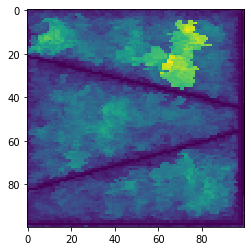

In [23]:
plt.imshow(results_frame.Sd[1])

In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

NameError: name 'results_frame_k' is not defined

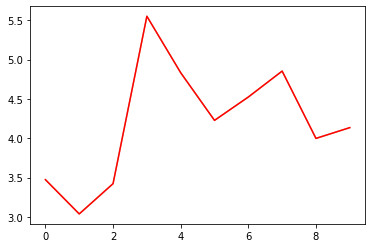

In [24]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Abs_error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Abs_error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Abs_error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

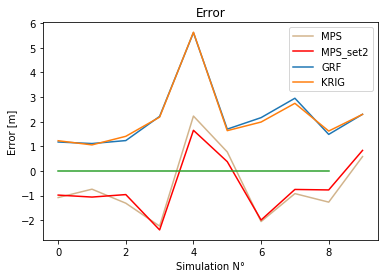

In [107]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

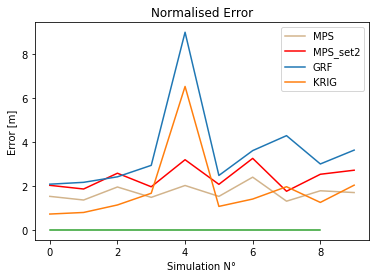

In [110]:
#etrange!!!!!!
plt.plot(results_frame[results_frame['Type']=='MPS'].Norm_Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Norm_Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Norm_Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


In [104]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS'].Volume.values[i][:])
    vol_MPS2.extend(results_frame_2[results_frame_2['Type']=='MPS'].Volume.values[i][:])

    #vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])
vol_KRIG.extend(results_frame_k[results_frame_k['Type']=='KRIG'].Volume.values)

    

Text(0.5, 0, 'Volume [m^2]')

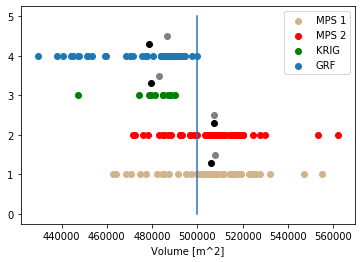

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')